#Assignment 1 - Neural Network Basics and Keras Models

The structure of the Assignment is as follows:

1. **Neural Network Basics:**

   We first want to refamiliarize ourselves with the basics of neural networks. We will perform a few operations and test some of the functions we will do later in the class.

2. **Keras Models**

   Next, we will use Keras' sequential API to build intuition around networks that have wider layers versus networks that have more layers.  Finally we'll use the Keras Functional API  to build and train a model.  


For reference, please consider the Lecture material for weeks 1 & 2 as well as the lesson notebooks:

* [Lesson Notebook from Week 1](https://colab.research.google.com/drive/11puLjBGup9K-dFaCnojCNfRqpHGnR6i3?usp=sharing)


**INSTRUCTIONS:**

* Questions in this notebook are always indicated as **QUESTION**, so you can search for this string to make sure you answered all of the questions. You are expected to fill out, run, and submit this notebook, as well as to answer the questions in the Gradescope **answers** file.  Please do **not** remove the output from your notebooks when you submit them as we'll look at the output as well as your code for grading purposes.  **We cannot award points if the output cells are empty.**

* **### YOUR CODE HERE** indicates that you are supposed to write code.


* **### --- Put your answer in Gradescope Q.0. Do not enter your answer here. --- ###** indicates where in the Gradescope answer sheet you are supposed to write your answer. Please put your answer in the requested format.  Some questions are multiple choice so you can select the appropriate answer. Other questions are fill in the blank so enter either a string or a raw number -- no executable code, for example "3,15,24" or 0.123 but **NOT** `dict[23]` or `my_variable_name`.

**GRADESCOPE:**
- We are **NOT** using the autograder for this assignment.
- We are using a Gradescope answer sheet to facilitate grading.

- The assignment notebook you submit must be named Assignment_1.ipynb.  The very last question asks you to upload your notebook.

- Please format your input and output strings to be user friendly
- Adding comments in your code is strongly suggested but won't be graded.
- If you are stuck on a problem or do not understand a question - please come to office hours or ask questions (please don't post your code though). If it is a coding problem send a private email to your instructor.
- You can ask TAs for extra help and 1 on 1 sessions!
- You may use any libraries from the Python Standard Library for this assignment: https://docs.python.org/3/library/

**REMINDER:**
You must cite all of your uses of AI to assist in the homework.  A space is provided at the very end of the notebook to do so.

## Neural Network Basics

### Brief Review of Machine Learning

In supervised learning, parametric models are those where the model is a function of a fixed form with a number of unknown _parameters_.  Together with a loss function and a training set, an optimizer can select parameters to minimize the loss with respect to the training set.  Common optimizers include stochastic gradient descent.  It tweaks the parameters slightly to move the loss "downhill" due to a small batch of examples from the training set.

### Part A:  Linear & Logistic Regression

You've likely seen linear regression before.  In linear regression, we fit a line (technically, hyperplane) that predicts a target variable, $y$, based on some features $x$.  The form of this model is affine (even if we call it "linear"):  

$$y_{hat} = xW + b$$

where $W$ and $b$ are weights and an offset, respectively, and are the parameters of this parametric model.  The loss function that the optimizer uses to fit these parameters is the squared error ($||\cdots||_2$) between the prediction and the ground truth in the training set.

You've also likely seen logistic regression, which is tightly related to linear regression.  Logistic regression also fits a line - this time separating the positive and negative examples of a binary classifier.  The form of this model is similar:

$$y_{hat} = \sigma(xW + b)$$

where again $W$ and $b$ are the parameters of this model, and $\sigma$ is the [sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function) which maps un-normalized scores ("logits") to values $\hat{y} \in [0,1]$ that represent probabilities. The loss function that the optimizer uses to fit these parameters is the [cross entropy](https://colab.research.google.com/drive/11puLjBGup9K-dFaCnojCNfRqpHGnR6i3?usp=sharing) between the prediction and the ground truth in the training set.

This pattern of an affine transform, $xW + b$, occurs over and over in machine learning.

**We'll use logistic regression as our running example for the rest of this part of the assignment.**


#### Short Answer Questions

Imagine you want to implement logistic regression:

* `z = xW + b`
* `y_hat = sigmoid(z)`

Where:
1.  `x` is an 11-dimensional feature vector
2.  `W` is the weight vector
3.  `b` is the bias term

What are the dimensions of `W` and `b`?  Recall that in logistic regression, `z` is just a scalar (commonly referred to as the "logit").

Sketch a picture of the whole equation using rectangles to illustrate the dimensions of `x`, `W`, and `b`.  See examples below for inspiration (though please label each dimension).  We don't ask you to submit this, but make sure you can do it!  It's the "print" debugging statement of neural networks!  It's also useful for reading papers... if you can't draw the shapes of all the tensors, you don't (yet) know what's going on!

**QUESTION:**

1.1 (1 pt) What are the dimensions of W?  (Hint... don't change the dimensionality of the answer.)



In [ ]:
### Q1.1 ### --- Put your answer in Gradescope Q.1. Do not enter your answer here. --- ###

In [ ]:
"""
x = [1 x 11]
W = [11 x 1]
b = [1 x 1]

[1 x 11].[11 x 1] + [1 x 1] = [1 x 1]
"""

**QUESTION:**

1.2. (1 pt) What are the dimensions of b?  (Hint... don't change the dimensionality of the answer.)
  

In [ ]:
### Q1.2 ### --- Put your answer in Gradescope Q.2. Do not enter your answer here. --- ###

In [ ]:
"""
x = [1 x 11]
W = [11 x 1]
b = [1 x 1]

[1 x 11].[11 x 1] + [1 x 1] = [1 x 1]
"""

### Part B: Batching

Let's say we want to perform inference using your model (parameters `W` and `b`) above on multiple examples instead of just one. On modern hardware (especially GPUs), we can do this efficiently by *batching*.

To do this, we stack up the feature vectors in x like in the diagram below.  Note that changing the number of examples you run on (i.e. your batch size) *does not* affect the number of parameters in your model.  You're just running the same thing in parallel (instead of running the above one feature vector at a time at a time).

![](https://github.com/daveschaaf/nlp-266/blob/main/assignments/batchaffine.png?raw=1)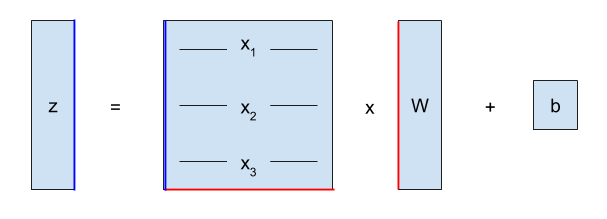

The red (# features) and blue (batch size) lines represent dimensions that are the same.


#### Short Answer Questions

If we have 11 features and running the model in parallel with 30 examples, what are the dimensions of:

1. `W` ?
2. `b` ?
3. `x` ?
4. `z` ?

_Hint:_ remember that your model parameters stay fixed!

**QUESTION:**

2.1. (1 pt) What are the dimensions of W?


In [ ]:
### Q2.1 ### --- Put your answer in Gradescope Q.3. Do not enter your answer here. --- ###

In [ ]:
"""
x = [30 x 11]
W = [11 x 1]
b = [1 x 1]

[30 x 11].[11 x 1] + [1 x 1] = [30 x 1]
"""

**QUESTION:**

2.2. (1 pt) What are the dimensions of b?


In [ ]:
### Q2.2 ### --- Put your answer in Gradescope Q.4. Do not enter your answer here. --- ###

In [ ]:
"""
x = [30 x 11]
W = [11 x 1]
b = [1 x 1]

[30 x 11].[11 x 1] + [1 x 1] = [30 x 1]
"""

**QUESTION:**

2.3. (1 pt) What are the dimensions of x?


In [ ]:
### Q2.3 ### --- Put your answer in Gradescope Q.5. Do not enter your answer here. --- ###

In [ ]:
"""
x = [30 x 11]
W = [11 x 1]
b = [1 x 1]

[30 x 11].[11 x 1] + [1 x 1] = [30 x 1]
"""

**QUESTION:**

2.4. (1 pt) What are the dimensions of z?


In [ ]:
### Q2.4 ### --- Put your answer in Gradescope Q.6. Do not enter your answer here. --- ###

In [ ]:
"""
x = [30 x 11]
W = [11 x 1]
b = [1 x 1]

[30 x 11].[11 x 1] + [1 x 1] = [30 x 1]
z = [30 x 1]
"""

### Part C: Logistic Regression - NumPy Implementation

In this section, we'll implement logistic regression by hand and compute a few values to make sure we understand what's going on!

Let's say your model has the following parameters:

In [2]:
import numpy as np

W = np.array([45,6,3,25,-1])
b = 5

If you want to run the model on the following three examples:

* [1, 2, 3, 4, 5]
* [0, 0, 0, 0, 5]
* [-3, -4, -12, -1, 1]

Construct the x matrix **such that you compute the answer all in one big batch** and compute the probability of the positive class for each.

In [6]:
# Import sigmoid.
from scipy.special import expit as sigmoid
# np.set_printoptions(suppress=True, precision=5)
### YOUR CODE HERE
x = np.array(
  [[1, 2, 3, 4, 5],
   [0, 0, 0, 0, 5],
   [-3, -4, -12, -1, 1]
  ]
)
logits = x@W + b
answer = sigmoid(logits)

print(answer)


### END YOUR CODE

[1.  0.5 0. ]


#### Short Answer Questions

**QUESTION:**

3.1. (2 pt) What is the probability of the positive class for [0, 0, 0, 0, 5] -- the middle choice?


In [7]:
### Q3.1 ### --- Put your answer in Gradescope Q.7. Do not enter your answer here. --- ###
print(answer[1])

0.5


**QUESTION:**

3.2 (2 pt) What is the cross entropy loss (Base 2) if the second example is positive?


In [13]:
### Q3.2 ### --- Put your answer in Gradescope Q.8. Do not enter your answer here. --- ###
p = answer[1]
ce = - np.dot(p, np.log2(1))
print(ce)

-0.0


### Part D: NumPy Feed Forward Neural Network

Let's do the same procedure for a simple feed-forward neural network.

Imagine you have a 3 layer network (hint: # of affines = # of layers. The affine is the W + b part of a layer).  Each hidden layer is size 10.  Just like before, you've already trained your model and you just want to run it forward.  For this exercise, let's say that each weight matrix is np.ones(...) and each bias term is [-1, -2, -3, ..., -n] if the bias term is $n$ long.  Compute the probability of the positive class for the three examples above, again in a single batch.

**Hint:  Draw the shapes of the matrices at each layer out on a piece of paper!  Include it with any questions you post to Ed Discussion.**

Assume your model uses a sigmoid as the nonlinearity for all layers.

In [ ]:
### YOUR CODE HERE


### END YOUR CODE

#### Short Answer Questions

**QUESTION:**

4.1. (2 pt) What is the probability of the third example in the batch?



In [ ]:
### Q4.1 ### --- Put your answer in Gradescope Q.9. Do not enter your answer here. --- ###

**QUESTION:**

4.2. (2pt) What is the cross-entropy loss (base 2) if the third example's label is negative?



In [ ]:
### Q4.2 ### --- Put your answer in Gradescope Q.10. Do not enter your answer here. --- ###

### Part E: Softmax

Recall that softmax(z) is a vector with the same length as z, and whose components are:  $softmax(z)_i = \frac{e^{z_i}}{\Sigma_j e^{z_j}}$.

#### Short Answer Questions

1. If the logits coming from the main body of the network are [4, 6, 8], what is the probability of the middle class?
2. What is the cross-entropy loss if the correct class is the last one? (i.e. corresponding to logit=8)?
3. If you had such a three-class classification problem, what would the dimensions of W and b be for the last layer of the feed forward neural network above?

**QUESTION:**

5.1. (2 pt) If the logits coming from the main body of the network are [4, 6, 8], what is the probability of the middle class?



In [ ]:
### Q5.1 ### --- Put your answer in Gradescope Q.11. Do not enter your answer here. --- ###

**QUESTION:**

5.2. (2pt) What is the cross-entropy loss (log base 2) if the correct class is the last (z=8)?


In [ ]:
### Q5.2 ### --- Put your answer in Gradescope Q.12. Do not enter your answer here. --- ###

**QUESTION:**

5.3. (2pt) If you had such a three-class classification problem, what would the dimensions of W and b be for the last layer of the feed forward neural network above?  First, what are the dimensions of W3 above if it were a three class problem instead of a binary one?



In [ ]:
### Q5.3 ### --- Put your answer in Gradescope Q.13. Do not enter your answer here. --- ###

**QUESTION:**

5.4. (2pt) What is the dimension of b3 above if it were a three class problem?



In [ ]:
### Q5.4 ### --- Put your answer in Gradescope Q.14. Do not enter your answer here. --- ###

## Machine Learning in Keras


### Brief Review of Machine Learning

In supervised learning, parametric models are those where the model is a function of a fixed form with a number of unknown _parameters_.  Together with a loss function and a training set, an optimizer can select parameters to minimize the loss with respect to the training set.  Common optimizers include stochastic gradient descent.  It tweaks the parameters slightly to move the loss "downhill" due to a small batch of examples from the training set.

### Linear & Logistic Regression

You've likely seen linear regression before.  In linear regression, we fit a line (technically, hyperplane) that predicts a target variable, $y$, based on some features $x$.  The form of this model is affine (even if we call it "linear"):  

$$y_{hat} = xW + b$$

where $W$ and $b$ are weights and an offset, respectively, and are the parameters of this parametric model.  The loss function that the optimizer uses to fit these parameters is the squared error ($||\cdots||_2$) between the prediction and the ground truth in the training set.

You've also likely seen logistic regression, which is tightly related to linear regression.  Logistic regression also fits a line - this time separating the positive and negative examples of a binary classifier.  The form of this model is similar:

$$y_{hat} = \sigma(xW + b)$$

where again $W$ and $b$ are the parameters of this model, and $\sigma$ is the [sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function) which maps un-normalized scores ("logits") to values $\hat{y} \in [0,1]$ that represent probabilities. The loss function that the optimizer uses to fit these parameters is the [cross entropy](../../materials/lesson_notebook/lesson_1_NN_Review.ipynb) between the prediction and the ground truth in the training set.

This pattern of an affine transform, $xW + b$, occurs over and over in machine learning.

### Preliminaries...

Before we do anything else, let's load our data and take a quick look at it.  In this example, we're going to build a (very) simple binary classifier based on two floating point features.

In [ ]:
import numpy as np

def generate_data(num_train, num_test):
    np.random.seed(1)
    num = num_train + num_test
    x0 = np.random.randn(num, 2) + 3.*np.array([1, 0])
    x1 = np.random.randn(num, 2) + 1.*np.array([-1, 0])
    X = np.vstack([x0, x1])
    y = np.concatenate([
        np.zeros(num), np.ones(num)])

    # Randomly shuffle the data
    shuf_idx = np.random.permutation(len(y))
    X = X[shuf_idx]
    y = y[shuf_idx]

    return X[:num_train], y[:num_train], X[num_train:num], y[num_train:num]


def generate_non_linear_data(num_train, num_test):
    np.random.seed(1)
    num = num_train + num_test
    x0 = np.random.randn(num, 2) + 4.*np.array([1, 0])
    x1 = np.random.randn(num, 2) + 4.*np.array([0, 1])
    x2 = np.random.randn(num, 2) + 4.*np.array([-1, 0])
    x3 = np.random.randn(num, 2) + 4.*np.array([0, -2])
    X = np.vstack([x0, x1, x2, x3])
    y = np.concatenate([
        np.zeros(num), np.ones(num),
        np.zeros(num), np.ones(num)])

    # Randomly shuffle the data
    shuf_idx = np.random.permutation(len(y))
    X = X[shuf_idx]
    y = y[shuf_idx]

    return X[:num_train], y[:num_train], X[num_train:num], y[num_train:num]

In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt

In [ ]:
X_train, y_train, X_test, y_test = generate_data(2500, 500) #large test size to make diagrams better
print(X_train.shape)
print(X_test.shape)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr');

### Training Logistic Regression

It's clear that the data is separable with a vertical line.  The simplest model we can use for this data is logistic regression.  Let's do that.

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import torch
import keras

print(keras.__version__)

In [ ]:
#####
## MAKE SURE YOU UNDERSTAND THIS CODE!!
##
## Look up keras.Sequential and keras.layers.Dense!
##
## You will need to use them to write your own model down below!
#####

# Sequential models are ones where the set of specified layers are stacked each on top of the previous.
linear_model = keras.Sequential([
    # Dense is an affine (xW + b) layer followed by an element wise nonlinearity.
    keras.layers.Dense(1, activation='sigmoid')
])

# adam optimizer is a fancier version of gradient descent.  You can read more about it here: https://arxiv.org/pdf/1412.6980.pdf
linear_model.compile(optimizer='adam',
              loss='binary_crossentropy',  # From information theory notebooks.
              metrics=['accuracy'])        # What metric to output as we train.

linear_model.fit(X_train, y_train, epochs=15)

**Hint:** You should expect to see an initial loss here of 0.2 - 1.2.  This is because a well-initialized random classifier tends to output a uniform distribution.  For each example in the batch, we either compute the cross-entropy loss of the label (`[1, 0]` or `[0, 1]`) against the model's output (`~[0.5, 0.5]`).  Both cases result in $-\lg(0.5) = lg(2) = 1.0$.

Of course, your random classifier won't output exactly uniform distributions (it's random after all), but you should anticipate it being pretty close.  If it's not, your initialization may be broken and make it hard for your network to learn.

**[Optional]** Some technical details... if your randomly initialized network is outputting very confident predictions, the loss computed may be very large while at the same time the sigmoids in the network are likely in saturation, quickly shrinking gradients.  The result is that you make tiny updates in the face of a huge loss.

Let's use our model to make predictions on the test set:

#### Short Answer Questions

**QUESTION:**

6.1. (2pt) What's the derivative of a relu(z) with respect to z if z = -5?



In [ ]:
### Q6.1 ### --- Put your answer in Gradescope Q.15. Do not enter your answer here. --- ###

**QUESTION:**

6.2. (2pt) What's the derivative of relu(z) with respect to z if z = 5

In [ ]:
### Q6.2 ### --- Put your answer in Gradescope Q.16. Do not enter your answer here. --- ###

**QUESTION:**

6.3 (2 pt): Why do you still use a sigmoid at the top of the binary classification network?

 - Its range matches what is allowed for a probability.
 - Sigmoid is convenient, but you lose nothing by using a Relu or Tanh
 - We don't use a sigmoid at the top of a binary classification network


In [ ]:
### Q6.3 ### --- Put your answer in Gradescope Q.17. Do not enter your answer here. --- ###

In [ ]:
predictions = linear_model.predict(X_test)
plt.scatter(X_test[:,0], X_test[:,1], c=predictions[:,0]>0.5, cmap='bwr')

### But what about a harder problem?

The case above, the data was linearly separable making it susceptible to a linear classifier.

But what if you had data that looked more like this?

In [ ]:
X_train, y_train, X_test, y_test = generate_non_linear_data(2500, 500)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr')

In [ ]:
linear_model.fit(X_train, y_train, epochs=10)

Again, let's make predictions on the test set...

In [ ]:
predictions = linear_model.predict(X_test)
plt.scatter(X_test[:,0], X_test[:,1], c=predictions[:,0]>0.5, cmap='bwr')

That isn't very good!

### Building a deeper network with the Keras Sequential API

Ok, now it's your turn.  Build a sequential neural network below and start to build intuition around the effects of the number of layers in the network and the number of neurons in each layer.  Try to achieve a loss less than 0.05.  Initialization is random, but try to make it happen "almost" always (e.g. at least 90% of the time). Let's look first at the number of layers.

What is the minimum number of hidden layers with the same number of neurons in each you can get away with and still achieve the desired loss on the training set?  the value of n should be constant across all your layers and n > 5.  Enter your code here and your answer in the answers cell for 6.4 below.

In [ ]:
deep_model = keras.Sequential([
    #
    # Hint, try "relu" as your activation function.
    # relu(z) = max(0, z).
    #     Note that: relu(z) = z when z > 0
    #                relu(z) = 0 otherwise
    #
    # See https://en.wikipedia.org/wiki/File:Ramp_function.svg
    #
    # This is the most common nonlinearity for the main body of the network as its derivative is
    # either 0 or 1, depending on the value of z.
    #
    # This means that the gradient doesn't tend to explode or vanish as you multiply more partial
    # derivative terms together.
    #
    # For this problem...
    #
    # Try toying with the trade offs between more narrow layers vs wider shallower networks:
    #   If we keep repeating the same hidden layer with n neurons:
    #    What's the minimum number of hidden layers you can get away with given a larger value of n?
    #    For this exercise the value of n should be constant across all your layers and n > 5

    ### YOUR CODE HERE




    ### END YOUR CODE

    # Think about why you still use a sigmoid at the top of your network.
    keras.layers.Dense(1, activation='sigmoid')
])

deep_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

deep_model.fit(X_train, y_train, epochs=10)

In [ ]:
predictions = deep_model.predict(X_test)
plt.scatter(X_test[:,0], X_test[:,1], c=predictions[:,0]>0.5, cmap='bwr')

**QUESTION:**

6.4. (2pt) For the sequential model, what is the minimum number of hidden layers with the same number of neurons in each (n where n > 5 neurons) you can get away with and still achieve the desired loss on the training set?



In [ ]:
### Q6.4 ### --- Put your answer in Gradescope Q.18. Do not enter your answer here. --- ###

Now let's examine the depth of the network.  What is the smallest number of neurons you can use in a layer in the network with the largest number of layers and still get the desired loss on the training set?   What's the smallest number of neurons (n) in each layer you can use if you use **four or more layers**?  Try to achieve a loss less than 0.05. Initialization is random, but try to make it happen "almost" always (e.g. at least 90% of the time). Enter your code here and your answer in the answers cell for 6.5 below.

In [ ]:
narrow_model = keras.Sequential([
    #
    # Hint, try "relu" as your activation function.
    # relu(z) = max(0, z).
    #     Note that: relu(z) = z when z > 0
    #                relu(z) = 0 otherwise
    #
    # See https://en.wikipedia.org/wiki/File:Ramp_function.svg
    #
    # This is the most common nonlinearity for the main body of the network as its derivative is
    # either 0 or 1, depending on the value of z.
    #
    # This means that the gradient doesn't tend to explode or vanish as you multiply more partial
    # derivative terms together.
    #
    # For this problem...
    #
    # Try toying with the trade offs between more layers vs wider networks:
    #   If we keep repeating the same hidden layer with n neurons:
    #    What's the smallest number of neurons (n) in each layer you can use
    #     if you use four or more layers?

    ### YOUR CODE HERE



    ### END YOUR CODE

    # Think about why you still use a sigmoid at the top of your network.
    keras.layers.Dense(1, activation='sigmoid')
])

narrow_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

narrow_model.fit(X_train, y_train, epochs=10)

In [ ]:
n_predictions = narrow_model.predict(X_test)
plt.scatter(X_test[:,0], X_test[:,1], c=n_predictions[:,0]>0.5, cmap='bwr')

**QUESTION:**

6.5. (2 pt) What is the smallest number of neurons (n) you can use in a layer in the network with a large number of layers (layers > 3) and still get the desired loss on the training set? (Assume all layers have the same number of neurons.)



In [ ]:
### Q6.5 ### --- Put your answer in Gradescope Q.19. Do not enter your answer here. --- ###

### Keras Functional API

Finally, let's do some initial exploration of the Keras Functional API. The code above used a Sequential model, which is a simplified way to create a Tensorflow model using Keras. As you can see above, we can build a Sequential model just by listing some layers, which Keras will attach one after the other. If we want to do anything fancier, though, like have multiple inputs or outputs, we need to use the Functional API.

Let's imagine that we want to take the input features we used above, but now we want to pass the same input into two separate Dense layers, then compare the vectors that come out of them. There isn't a practical reason to do this right now, we're just getting familiar with some more Keras layer operations, that you might use in the future when you do have a reason (e.g. if you have two different types of input or you want to generate multiple different outputs).

With the Functional API, we first instantiate each layer, specifying any parameters like the dimension (number of neurons). Then, we "call" the layer we just created, using another set of parentheses to pass in whatever the input to that layer is. That's how we connect the layers, we save the output from one layer and then pass it as input to the layer that should come after. Essentially we will build our model by repeating:

```layer_output = layer(earlier_layer_output)```

The order in which we define the layers does not matter.  Once defined we can connect them.


We also have to explicitly define an input layer, so that we can pass it into the first hidden layer in the model. We also have to define an output layer.

You will redefine the sequential model you just created but do so using the functional API.



In [ ]:
# Define the input layer
input_layer = keras.layers.Input(shape=(2,), dtype='int64')


#Here are the layers you should use

dense_1 = keras.layers.Dense(10, activation='relu')
dense_2 = keras.layers.Dense(10, activation='relu')
dense_3 = keras.layers.Dense(10, activation='relu')

# Now call the dense layers with the right input for each, to connect the network

### YOUR CODE HERE




### END YOUR CODE


# Define a binary classification layer like we used in the model above
classification_layer = keras.layers.Dense(1, activation='sigmoid')(dense_3_out)

You've defined all of your layers and connnected them together. Now you just need a few more lines of code to define the overall model, then compile it and train it like you did with the Sequential model.

To define the model, you specify the initial inputs and final outputs. You've already defined how the layers are connected internally, so as long as there's a path from the initial inputs to the final outputs, you're good.

In [ ]:
# Define the complete model, specifying the overall inputs and outputs
func_model = keras.models.Model(inputs=[input_layer], outputs=[classification_layer])

# Compile the model, specifying the loss, optimizer, etc to use in training
func_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

func_model.fit(X_train, y_train, epochs=10)

**QUESTION:**

6.6. (2pt) What is the final accuracy score you get after training the functional model for 10 epochs?  Please copy and paste your answer in to the answers cell below.

In [ ]:
### Q6.6 ### --- Put your answer in Gradescope Q.20. Do not enter your answer here. --- ###

In [ ]:
predictions = func_model.predict(X_test)
plt.scatter(X_test[:,0], X_test[:,1], c=predictions[:,0]>0.5, cmap='bwr')

# Congratulations...
... you've trained a nonlinear classifier with Keras using the sequential and the functional APIs!


# AI Citation Section

*DOUBLE CLICK HERE TO ADD GEN AI CITATIONS*

and cite the models you have used and what you've used them to do.

Cite models as follows (roughly equivalent to Chicago Manual of Style format)

Task or Prompt, Model, Publisher, Date, URL to conversation if publicly available, for example:

Polish wording, Gemini3, Google, 1/1/26, https://chatgpt.com/share/66fb0ff3-7280-8009-93a9-d956f41234567b


#Finish Assignment

To complete the assignment, download this completed notebook as an .ipynb file to your laptop and then upload that .ipynb file into Gradescope.  We expect to find a file named Assignment_1.ipynb in Gradescope associated with you.

**It is your responsibility to make sure that you have uploaded the correct file with your code, the outputs of running your code and other cells, and the answer cells filled in by you.  We will grade you based on a combination of the answer cells and the code and output of the code you have written.**